# 03 — Sleep-EDF Feature Engineering

This notebook extends the subject-level Sleep-EDF feature table with derived sleep metrics.

## Objectives

- load the subject-level sleep feature dataset;
- check feature completeness and numeric ranges;
- create interpretable derived sleep features;
- visualize engineered features;
- save the engineered feature table for downstream analysis.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the project root by looking for README.md and data/."""
    for path in [start, *start.parents]:
        if (path / "README.md").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Project root not found. Make sure README.md and data/ exist."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "notebooks" / "images"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

features_path = PROCESSED_DIR / "sleep_features_all_subjects.csv"
engineered_path = PROCESSED_DIR / "sleep_features_engineered.csv"


## Load sleep feature dataset

The input file is expected at `data/processed/sleep_features_all_subjects.csv`.


In [3]:
if not features_path.exists():
    raise FileNotFoundError(
        "Expected file not found: data/processed/sleep_features_all_subjects.csv. "
        "Run notebook 02 first."
    )

features_df = pd.read_csv(features_path)

display(features_df.head())
display(pd.DataFrame({"column": features_df.columns, "dtype": features_df.dtypes.astype(str).values}))


,subject_id,n_episodes,recording_hours,sleep_period_hours,total_sleep_hours,sleep_latency_min,rem_latency_min,fragmentation,wake_pct_in_sleep_period,rem_pct_of_tst,n1_pct_of_tst,n2_pct_of_tst,deep_sleep_pct_of_tst,sleep_efficiency
0,subject_001,153,22.083333,6.008333,5.441667,510.5,89.0,151,9.431345,19.14242,8.882083,38.284839,33.690658,0.905687


,column,dtype
0,subject_id,str
1,n_episodes,int64
2,recording_hours,float64
3,sleep_period_hours,float64
4,total_sleep_hours,float64
5,sleep_latency_min,float64
6,rem_latency_min,float64
7,fragmentation,int64
8,wake_pct_in_sleep_period,float64
9,rem_pct_of_tst,float64


## Data quality checks

The table is checked for missing values and basic numeric ranges before deriving additional features.


In [4]:
missing_summary = (
    features_df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_values"})
)

display(missing_summary)

numeric_summary = features_df.select_dtypes(include=[np.number]).describe().T
display(numeric_summary)


,feature,missing_values
0,subject_id,0
1,n_episodes,0
2,recording_hours,0
3,sleep_period_hours,0
4,total_sleep_hours,0
5,sleep_latency_min,0
6,rem_latency_min,0
7,fragmentation,0
8,wake_pct_in_sleep_period,0
9,rem_pct_of_tst,0


,count,mean,std,min,25%,50%,75%,max
n_episodes,1.0,153.000000,NaN,153.000000,153.000000,153.000000,153.000000,153.000000
recording_hours,1.0,22.083333,NaN,22.083333,22.083333,22.083333,22.083333,22.083333
sleep_period_hours,1.0,6.008333,NaN,6.008333,6.008333,6.008333,6.008333,6.008333
total_sleep_hours,1.0,5.441667,NaN,5.441667,5.441667,5.441667,5.441667,5.441667
sleep_latency_min,1.0,510.500000,NaN,510.500000,510.500000,510.500000,510.500000,510.500000
rem_latency_min,1.0,89.000000,NaN,89.000000,89.000000,89.000000,89.000000,89.000000
fragmentation,1.0,151.000000,NaN,151.000000,151.000000,151.000000,151.000000,151.000000
wake_pct_in_sleep_period,1.0,9.431345,NaN,9.431345,9.431345,9.431345,9.431345,9.431345
rem_pct_of_tst,1.0,19.142420,NaN,19.142420,19.142420,19.142420,19.142420,19.142420
n1_pct_of_tst,1.0,8.882083,NaN,8.882083,8.882083,8.882083,8.882083,8.882083


## Derived sleep features

The engineered features below are intentionally interpretable:

- sleep efficiency as a percentage;
- wake time during the sleep period;
- non-REM composition;
- light sleep percentage;
- sleep maintenance index;
- fragmentation per hour;
- simplified sleep duration category.


In [5]:
engineered_df = features_df.copy()

if "sleep_efficiency" in engineered_df.columns:
    engineered_df["sleep_efficiency_pct"] = engineered_df["sleep_efficiency"] * 100

if {"sleep_period_hours", "total_sleep_hours"}.issubset(engineered_df.columns):
    engineered_df["wake_after_sleep_onset_hours"] = (
        engineered_df["sleep_period_hours"] - engineered_df["total_sleep_hours"]
    ).clip(lower=0)

if {"n1_pct_of_tst", "n2_pct_of_tst"}.issubset(engineered_df.columns):
    engineered_df["light_sleep_pct_of_tst"] = (
        engineered_df["n1_pct_of_tst"] + engineered_df["n2_pct_of_tst"]
    )

if {"rem_pct_of_tst", "deep_sleep_pct_of_tst"}.issubset(engineered_df.columns):
    engineered_df["restorative_sleep_pct_of_tst"] = (
        engineered_df["rem_pct_of_tst"] + engineered_df["deep_sleep_pct_of_tst"]
    )

if {"fragmentation", "sleep_period_hours"}.issubset(engineered_df.columns):
    engineered_df["fragmentation_per_hour"] = np.where(
        engineered_df["sleep_period_hours"] > 0,
        engineered_df["fragmentation"] / engineered_df["sleep_period_hours"],
        np.nan,
    )

if {"total_sleep_hours", "sleep_period_hours"}.issubset(engineered_df.columns):
    engineered_df["sleep_maintenance_index"] = np.where(
        engineered_df["sleep_period_hours"] > 0,
        engineered_df["total_sleep_hours"] / engineered_df["sleep_period_hours"],
        np.nan,
    )


def categorize_sleep_duration(hours: float) -> str:
    if pd.isna(hours):
        return "unknown"
    if hours < 6:
        return "short"
    if hours <= 9:
        return "typical"
    return "long"


if "total_sleep_hours" in engineered_df.columns:
    engineered_df["sleep_duration_category"] = engineered_df["total_sleep_hours"].apply(
        categorize_sleep_duration
    )

display(engineered_df.head())


,subject_id,n_episodes,recording_hours,sleep_period_hours,total_sleep_hours,sleep_latency_min,rem_latency_min,fragmentation,wake_pct_in_sleep_period,rem_pct_of_tst,...,n2_pct_of_tst,deep_sleep_pct_of_tst,sleep_efficiency,sleep_efficiency_pct,wake_after_sleep_onset_hours,light_sleep_pct_of_tst,restorative_sleep_pct_of_tst,fragmentation_per_hour,sleep_maintenance_index,sleep_duration_category
0,subject_001,153,22.083333,6.008333,5.441667,510.5,89.0,151,9.431345,19.14242,...,38.284839,33.690658,0.905687,90.568655,0.566667,47.166922,52.833078,25.131761,0.905687,short


## Engineered feature overview

The following table shows a compact subset of clinically interpretable sleep features. The labels are descriptive and should not be interpreted as medical assessment.


In [6]:
overview_columns = [
    "subject_id",
    "total_sleep_hours",
    "sleep_period_hours",
    "sleep_efficiency_pct",
    "wake_after_sleep_onset_hours",
    "fragmentation_per_hour",
    "rem_pct_of_tst",
    "deep_sleep_pct_of_tst",
    "restorative_sleep_pct_of_tst",
    "sleep_duration_category",
]

available_overview_columns = [
    col for col in overview_columns if col in engineered_df.columns
]

display(engineered_df[available_overview_columns])


,subject_id,total_sleep_hours,sleep_period_hours,sleep_efficiency_pct,wake_after_sleep_onset_hours,fragmentation_per_hour,rem_pct_of_tst,deep_sleep_pct_of_tst,restorative_sleep_pct_of_tst,sleep_duration_category
0,subject_001,5.441667,6.008333,90.568655,0.566667,25.131761,19.14242,33.690658,52.833078,short


## Visualize engineered features

A compact bar chart is generated for selected numeric features. This is useful for checking feature scale and interpretability.


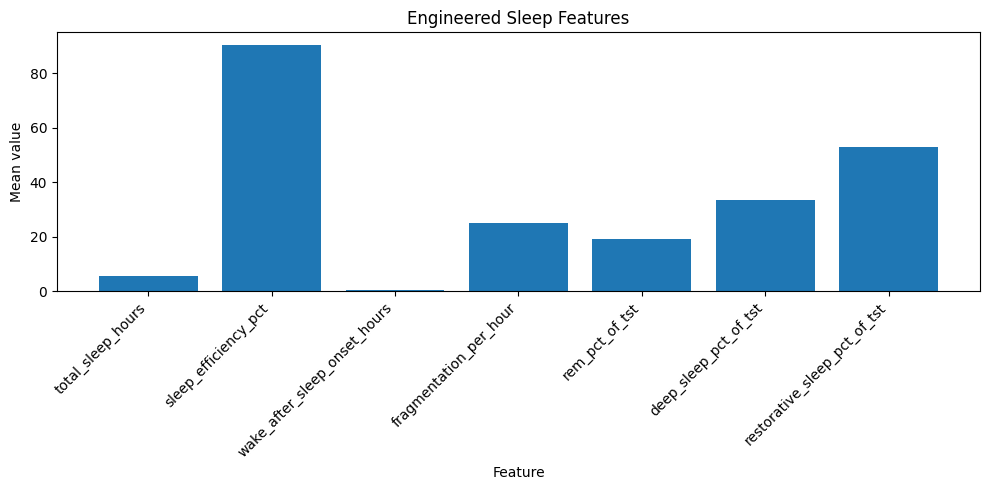

,feature,mean_value
0,total_sleep_hours,5.441667
1,sleep_efficiency_pct,90.568655
2,wake_after_sleep_onset_hours,0.566667
3,fragmentation_per_hour,25.131761
4,rem_pct_of_tst,19.142420
5,deep_sleep_pct_of_tst,33.690658
6,restorative_sleep_pct_of_tst,52.833078


In [7]:
plot_features = [
    "total_sleep_hours",
    "sleep_efficiency_pct",
    "wake_after_sleep_onset_hours",
    "fragmentation_per_hour",
    "rem_pct_of_tst",
    "deep_sleep_pct_of_tst",
    "restorative_sleep_pct_of_tst",
]

available_plot_features = [
    col for col in plot_features if col in engineered_df.columns
]

plot_values = (
    engineered_df[available_plot_features]
    .mean(numeric_only=True)
    .reset_index()
)

plot_values.columns = ["feature", "mean_value"]

plt.figure(figsize=(10, 5))
plt.bar(plot_values["feature"], plot_values["mean_value"])
plt.xlabel("Feature")
plt.ylabel("Mean value")
plt.title("Engineered Sleep Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = IMAGES_DIR / "03_engineered_sleep_features.png"
plt.savefig(plot_path, dpi=150)

plt.show()

display(plot_values)


## Save engineered feature table

The engineered dataset is saved for later sleep-health and cognition analysis notebooks.


In [8]:
engineered_df.to_csv(engineered_path, index=False)

print(f"Saved engineered features to: {engineered_path.relative_to(PROJECT_ROOT)}")
display(engineered_df.head())


Saved engineered features to: data\processed\sleep_features_engineered.csv


,subject_id,n_episodes,recording_hours,sleep_period_hours,total_sleep_hours,sleep_latency_min,rem_latency_min,fragmentation,wake_pct_in_sleep_period,rem_pct_of_tst,...,n2_pct_of_tst,deep_sleep_pct_of_tst,sleep_efficiency,sleep_efficiency_pct,wake_after_sleep_onset_hours,light_sleep_pct_of_tst,restorative_sleep_pct_of_tst,fragmentation_per_hour,sleep_maintenance_index,sleep_duration_category
0,subject_001,153,22.083333,6.008333,5.441667,510.5,89.0,151,9.431345,19.14242,...,38.284839,33.690658,0.905687,90.568655,0.566667,47.166922,52.833078,25.131761,0.905687,short


## Summary

This notebook converts the basic sleep feature table into a richer engineered feature dataset. The derived metrics are designed to be interpretable and reusable in downstream exploratory analyses.

The results remain exploratory and should not be interpreted as clinical sleep scoring.
